# What the IDTAP annotations actually contain

An audit of the ground truth available for automatic trajectory transcription, read entirely from the canonical dataset under `output/canonical/v1/`.

Seven findings, each computed live from the data rather than quoted:

1. **What annotation information exists** — and which fields are populated versus merely defined
2. **The annotation tiles the timeline** — there are no temporal gaps to interpret
3. **"Silent" is an annotation, not a measurement** — it conflates a musical rest with an untranscribed region
4. **A real annotated timeline** — trajectory intervals with pitch contours reconstructed from the stored shape parameters
5. **Raw versus derived** — and the proof that the raw block loses nothing
6. **Type-0 canonicalization** — merging without destroying the original annotation
7. **Grouped splits** — the duplicate-audio leakage that recording-level splitting would miss

## Prerequisites

Build the canonical dataset first, from the repository root:

```bash
python dataset/canonical/build.py     # emit recording documents and index tables
python dataset/canonical/splits.py    # emit the split manifests
```

Everything below reads from disk only, so no IDTAP network access is needed.

> This notebook draws **no acoustic conclusion** about unannotated or silent-labelled regions. It reports what the annotators asserted and leaves the interpretation open.

In [1]:
from __future__ import annotations

import csv
import json
import math
import sys
from collections import Counter, defaultdict
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt

# pandas is unusable in this environment (numpy ABI mismatch), so the whole
# canonical stage — this notebook included — stays on stdlib csv/json.
CANONICAL = PROJECT_ROOT / "output" / "canonical" / "v1"
if not (CANONICAL / "index" / "recordings.csv").exists():
    raise SystemExit(
        f"No canonical dataset found at {CANONICAL}\n"
        "Build it first:  python dataset/canonical/build.py"
    )


def read_index(name: str) -> list[dict[str, str]]:
    with (CANONICAL / "index" / f"{name}.csv").open(newline="") as handle:
        return list(csv.DictReader(handle))


def load_json(path: Path) -> dict:
    return json.loads(path.read_text())


recordings = read_index("recordings")
trajectories = read_index("trajectories")
transitions = read_index("transitions")
docs = {
    row["recording_id"]: load_json(
        CANONICAL / "recordings" / f"{row['recording_id']}.json"
    )
    for row in recordings
}

TYPE_NAME = {int(t["type_id"]): t["type_name"] for t in trajectories}
TYPE_IDS = sorted(TYPE_NAME)
ANY_DOC = next(iter(docs.values()))

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

print(f"schema_version {ANY_DOC['schema_version']}")
print(f"{len(recordings):>6} recordings")
print(f"{len(trajectories):>6} trajectories")
print(f"{len(transitions):>6} transitions")
print(f"{len(TYPE_IDS):>6} distinct trajectory types present: {TYPE_IDS}")
print()
print("derivation parameters recorded with every document:")
for key, value in ANY_DOC["derivation_params"].items():
    print(f"  {key} = {value!r}")

schema_version 1.0
    17 recordings
  5209 trajectories
  5189 transitions
    10 distinct trajectory types present: [0, 1, 2, 3, 4, 5, 6, 7, 12, 13]

derivation parameters recorded with every document:
  time_tolerance_s = 1e-06
  pitch_match_rule = 'exact_swara_oct_raised_log_offset'
  start_time_source = 'stored_offsets'
  traj_id_scheme = 'recording:lane:phrase:num'
  audio_duration_tolerance_s = 0.05
  type0_merge_across_phrase_boundary = True
  pitch_ratios_source = 'raga_stratified_ratios'


## Finding 1 — What annotation information exists

Two questions that are easy to conflate: which fields the IDTAP data model *defines*, and which fields the annotators actually *filled in*. The second chart answers the one that matters for training.

Note the trajectory-type imbalance: `Bend: Simple Multiple` (id 6) and `Fixed` (id 0) dominate, while `Bend: Reverse Ladle` (id 5) is nearly absent.

recording_id               instrument  raga              dur_s  trajs  units lanes non-sil  soloist
---------------------------------------------------------------------------------------------------
6824de49abc4705438ce918b   Sarangi     Basant Mukhari    592.0    543    540     2   0.707  Abdul Latif Khan
6417585554a0bfbd8de2d3ff   Vocal (M)   Multani           908.9   1873   1870     2   0.564  Abdul Wahid Khan
65e4a79cc7b694145529a3f1   Sitar       Mala             1904.1     62     62     1   0.010  Vilayat Khan
68f53fbf9d93a4cd2923711c   Vocal (M)   Darbari Kanada   1500.0     87     87     2   0.026  Amir Khan
645ff354deeaf2d1e33b3c44   Vocal (F)   Bhairavi          205.0    465    457     1   0.775  Begum Akhtar
6491d48d608d1718e0311003   Vocal (F)   Bhairavi          995.0    169    164     1   0.050  Siddheswari Devi
68d85d4570785f961df2499d   Vocal (M)   Purva Kalyan (M  2192.5    188    188     4   0.043  Bade Ghulam Ali Khan
6503e348d9ff49d3988d0b3f   Sitar       Bhopali/B

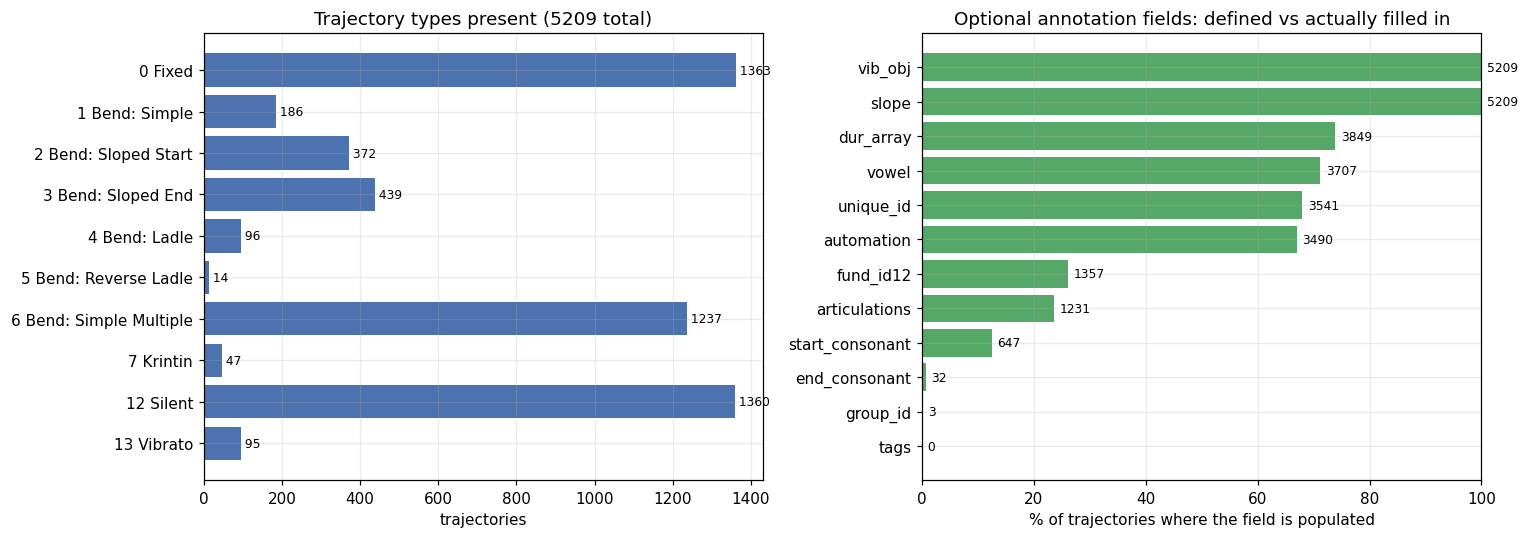

Fields that exist in the IDTAP model but are never populated here:
  tags

meters / tala: 0 across all recordings


In [2]:
header = (
    f"{'recording_id':26s} {'instrument':11s} {'raga':15s} {'dur_s':>7s} "
    f"{'trajs':>6s} {'units':>6s} {'lanes':>5s} {'non-sil':>7s}  soloist"
)
print(header)
print("-" * len(header))
for row in sorted(recordings, key=lambda r: r["title"]):
    print(
        f"{row['recording_id']:26s} {row['solo_instrument'][:11]:11s} "
        f"{row['raga_name'][:15]:15s} {float(row['audio_duration_s']):7.1f} "
        f"{int(row['n_trajectories']):6d} {int(row['n_canonical_units']):6d} "
        f"{int(row['n_lanes']):5d} "
        f"{float(row['annotated_non_silent_fraction']):7.3f}  {row['soloist']}"
    )

# Lanes are concurrent voices (track:string), so a second lane means a
# simultaneous part, not a continuation of the first.
lane_counts = Counter(t["lane_id"] for t in trajectories)
print(f"\nlanes across the corpus: {dict(sorted(lane_counts.items()))}")

# --- which trajectory types occur -----------------------------------------
type_counts = Counter(int(t["type_id"]) for t in trajectories)

# --- which raw fields the annotators actually populated --------------------
OPTIONAL_RAW_FIELDS = [
    "dur_array", "slope", "vib_obj", "articulations", "automation",
    "vowel", "start_consonant", "end_consonant",
    "fund_id12", "group_id", "unique_id", "tags",
]
populated: Counter[str] = Counter()
n_traj = 0
for doc in docs.values():
    for entry in doc["trajectories"]:
        n_traj += 1
        for field in OPTIONAL_RAW_FIELDS:
            value = entry["raw"].get(field)
            if value not in (None, {}, [], ""):
                populated[field] += 1

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5))

labels = [f"{i} {TYPE_NAME[i]}" for i in TYPE_IDS]
left.barh(labels, [type_counts[i] for i in TYPE_IDS], color="#4c72b0")
left.invert_yaxis()
left.set_xlabel("trajectories")
left.set_title(f"Trajectory types present ({n_traj} total)")
for i, type_id in enumerate(TYPE_IDS):
    left.text(type_counts[type_id], i, f" {type_counts[type_id]}", va="center", fontsize=8)

order = sorted(OPTIONAL_RAW_FIELDS, key=lambda f: populated[f])
pct = [100 * populated[f] / n_traj for f in order]
colors = ["#c44e52" if p == 0 else "#55a868" for p in pct]
right.barh(order, pct, color=colors)
right.set_xlim(0, 100)
right.set_xlabel("% of trajectories where the field is populated")
right.set_title("Optional annotation fields: defined vs actually filled in")
for i, (field, value) in enumerate(zip(order, pct)):
    right.text(value + 1, i, f"{populated[field]}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("Fields that exist in the IDTAP model but are never populated here:")
for field in order:
    if populated[field] == 0:
        print(f"  {field}")
print(f"\nmeters / tala: {sum(len(d['structure']['meters']) for d in docs.values())} across all recordings")

## Finding 2 — The annotation tiles the timeline

This is the single most consequential structural fact. Trajectories do not sit as islands in a sea of unlabelled audio: consecutive annotations *touch*, end-to-end, for the entire duration of every recording. There is no gap to interpret as anything.

The schema still models gaps and overlaps (`interval_relation` is one of `meets` / `gap` / `overlap`) because assuming contiguity would be unsafe — the library helper `Piece.traj_start_times` re-derives string-0 times by cumulatively summing durations, which would *manufacture* contiguity whether or not the source data had it. The canonical builder instead reads the stored `phrase.start_time + traj.start_time` offsets, so the result below is a measurement rather than an artifact.

interval_relation over 5189 consecutive pairs: {'meets': 5189}
classification tolerance: 1e-06 s

gap_s exactly 0.0        : 4883
gap_s with any residual  : 306
largest residual         : 2.274e-13 s (2.27e-07 x tolerance)
gap_s beyond tolerance   : 0

annotation-vs-audio duration mismatch across 17 recordings:
  max 7.81e-05 s   (tolerance 0.05 s)


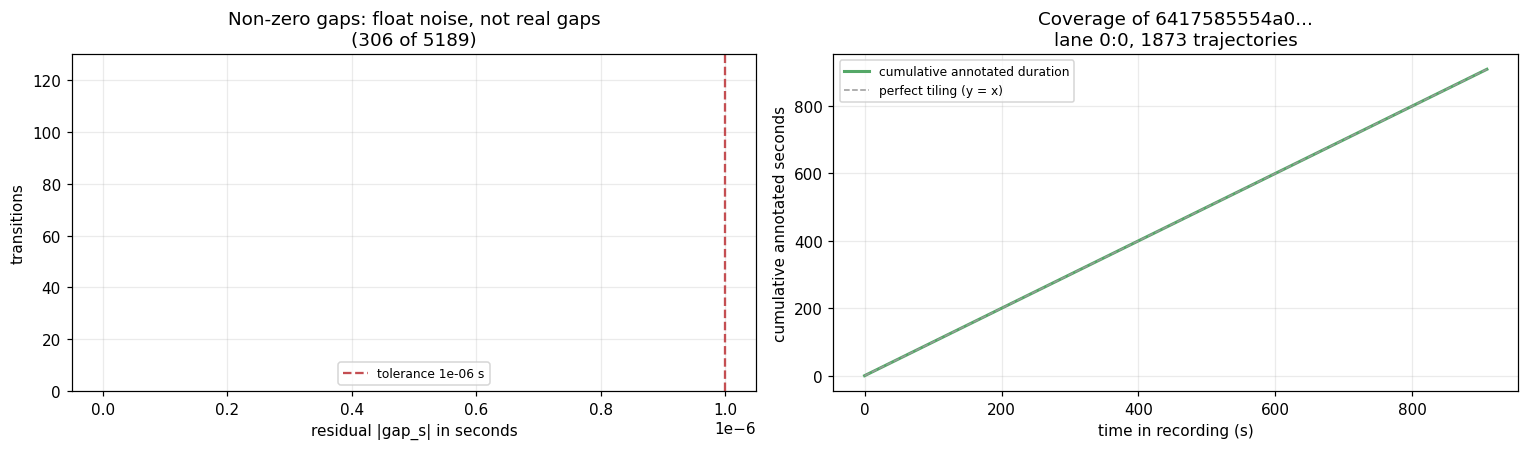

The green line lies on y = x: the annotation covers the recording with no holes.


In [3]:
tolerance = ANY_DOC["derivation_params"]["time_tolerance_s"]
relations = Counter(t["interval_relation"] for t in transitions)
gaps = [abs(float(t["gap_s"])) for t in transitions]
residual = sorted(g for g in gaps if g > 0.0)

print(f"interval_relation over {len(transitions)} consecutive pairs: {dict(relations)}")
print(f"classification tolerance: {tolerance} s")
print()
print(f"gap_s exactly 0.0        : {sum(1 for g in gaps if g == 0.0)}")
print(f"gap_s with any residual  : {len(residual)}")
if residual:
    print(f"largest residual         : {max(residual):.3e} s "
          f"({max(residual) / tolerance:.2e} x tolerance)")
print(f"gap_s beyond tolerance   : {sum(1 for g in gaps if g > tolerance)}")

# Coverage: does the annotation span the whole audio file?
deltas = [abs(float(r["audio_vs_annotation_delta_s"])) for r in recordings]
print(f"\nannotation-vs-audio duration mismatch across {len(recordings)} recordings:")
print(f"  max {max(deltas):.2e} s   (tolerance {ANY_DOC['derivation_params']['audio_duration_tolerance_s']} s)")

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 4.2))

if residual:
    left.hist(residual, bins=40, color="#4c72b0")
    left.set_xlabel("residual |gap_s| in seconds")
    left.set_ylabel("transitions")
    left.set_title(f"Non-zero gaps: float noise, not real gaps\n({len(residual)} of {len(gaps)})")
    left.axvline(tolerance, color="#c44e52", ls="--",
                 label=f"tolerance {tolerance:g} s")
    left.legend(fontsize=8)
else:
    left.text(0.5, 0.5, "every gap is exactly 0.0", ha="center", va="center")
    left.set_axis_off()

# Cumulative coverage of one recording: annotated intervals against audio length.
demo_id = max(recordings, key=lambda r: int(r["n_trajectories"]))["recording_id"]
demo = docs[demo_id]
lane = demo["coverage"]["silence_scope_lane_id"]
spans = [
    (e["derived"]["start_s"], e["derived"]["end_s"])
    for e in demo["trajectories"]
    if e["lane_id"] == lane
]
covered = 0.0
xs, ys = [0.0], [0.0]
for start, end in spans:
    covered += end - start
    xs.append(end)
    ys.append(covered)
right.plot(xs, ys, color="#55a868", lw=2, label="cumulative annotated duration")
right.plot([0, demo["coverage"]["audio_duration_s"]],
           [0, demo["coverage"]["audio_duration_s"]],
           color="0.6", ls="--", lw=1, label="perfect tiling (y = x)")
right.set_xlabel("time in recording (s)")
right.set_ylabel("cumulative annotated seconds")
right.set_title(f"Coverage of {demo_id[:12]}...\nlane {lane}, {len(spans)} trajectories")
right.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("The green line lies on y = x: the annotation covers the recording with no holes.")

## Finding 3 — "Silent" is an annotation, not a measurement

Because the timeline is fully tiled, silence is *explicit*: it is trajectory type 12, an interval the annotator positively marked. That sounds like clean ground truth, and for short intervals it probably is.

The problem is scale. A 1,600-second "Silent" trajectory inside a 1,690-second recording is not a musical rest — it is the part nobody transcribed. The two meanings share one label and the data offers no field that distinguishes them.

The chart below is therefore a **transcription-density plot**, not a silence plot. A recording that is 98% "Silent" tells us about annotator effort, not about the audio.

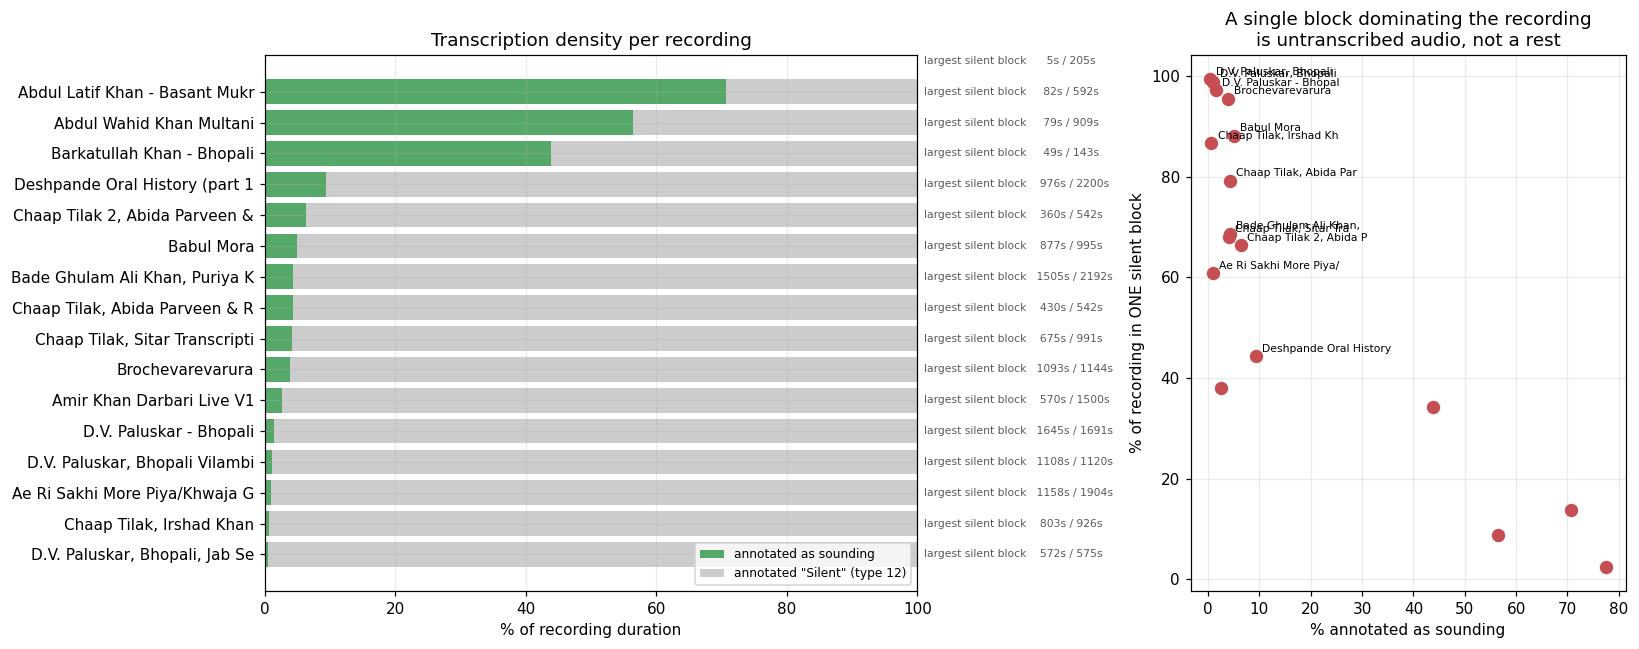

Recordings more than half transcribed: 3 of 17
  6417585554a0bfbd8de2d3ff  0.564  Abdul Wahid Khan Multani
  6824de49abc4705438ce918b  0.707  Abdul Latif Khan - Basant Mukrahi
  645ff354deeaf2d1e33b3c44  0.775  Babul Mora

Largest single 'Silent' trajectory: 1644.8s inside a 1691.1s recording (D.V. Paluskar - Bhopali)
Treating that as ground-truth silence would poison any silence detector.

Silent trajectories carrying a pitch array : 35
Silent trajectories missing fund_id12      : 3   <- Trajectory.compute raises on these


In [4]:
rows = sorted(recordings, key=lambda r: float(r["annotated_non_silent_fraction"]))
labels = [f"{r['title'][:30]}" for r in rows]
non_silent = [float(r["annotated_non_silent_fraction"]) * 100 for r in rows]
silent = [100 - v for v in non_silent]
biggest_block = [float(r["max_single_silent_annotation_s"]) for r in rows]
durations = [float(r["audio_duration_s"]) for r in rows]

fig, (left, right) = plt.subplots(1, 2, figsize=(15, 6),
                                  gridspec_kw={"width_ratios": [3, 2]})

left.barh(labels, non_silent, color="#55a868", label="annotated as sounding")
left.barh(labels, silent, left=non_silent, color="#cccccc",
          label='annotated "Silent" (type 12)')
left.set_xlim(0, 100)
left.set_xlabel("% of recording duration")
left.set_title("Transcription density per recording")
left.legend(fontsize=8, loc="lower right")
for i, (frac, block, total) in enumerate(zip(non_silent, biggest_block, durations)):
    left.text(101, i, f"largest silent block {block:6.0f}s / {total:.0f}s",
              va="center", fontsize=7, color="0.35")

# How much of each recording is one single silent block?
share = [100 * b / d for b, d in zip(biggest_block, durations)]
right.scatter(non_silent, share, s=60, color="#c44e52", zorder=3)
right.set_xlabel("% annotated as sounding")
right.set_ylabel("% of recording in ONE silent block")
right.set_title("A single block dominating the recording\nis untranscribed audio, not a rest")
for row, x, y in zip(rows, non_silent, share):
    if y > 40:
        right.annotate(row["title"][:22], (x, y), fontsize=7,
                       xytext=(4, 3), textcoords="offset points")

plt.tight_layout()
plt.show()

dense = [r for r in rows if float(r["annotated_non_silent_fraction"]) > 0.5]
print(f"Recordings more than half transcribed: {len(dense)} of {len(rows)}")
for r in dense:
    print(f"  {r['recording_id']}  {float(r['annotated_non_silent_fraction']):.3f}  {r['title']}")

longest = max(rows, key=lambda r: float(r["max_single_silent_annotation_s"]))
print(
    f"\nLargest single 'Silent' trajectory: "
    f"{float(longest['max_single_silent_annotation_s']):.1f}s inside a "
    f"{float(longest['audio_duration_s']):.1f}s recording ({longest['title']})"
)
print("Treating that as ground-truth silence would poison any silence detector.")

# Silent trajectories that nonetheless carry a pitch - an upstream data quirk,
# preserved verbatim rather than normalised away.
with_pitch = [
    e for doc in docs.values() for e in doc["trajectories"]
    if e["derived"]["is_silent_annotation"] and e["raw"]["pitches"]
]
no_fund = [
    e for doc in docs.values() for e in doc["trajectories"]
    if e["derived"]["is_silent_annotation"] and e["raw"].get("fund_id12") is None
]
print(f"\nSilent trajectories carrying a pitch array : {len(with_pitch)}")
print(f"Silent trajectories missing fund_id12      : {len(no_fund)}"
      "   <- Trajectory.compute raises on these")

## Finding 4 — A real annotated timeline

A trajectory is not a pitch curve. It is a *parametric shape*: a type id, an ordered list of discrete pitch control points, a duration, a `dur_array` of segment fractions, and a `slope` exponent. The continuous contour is generated on demand by `Trajectory.compute(x, log_scale=True)` for `x` in `[0, 1]`.

That distinction is the most valuable untapped asset in this dataset: it means a dense, sample-accurate f0 target can be generated for the whole sounding timeline without any new annotation. The plot below does exactly that — reconstructing each trajectory from its stored `raw` block and evaluating the contour.

Silent-annotated intervals are shaded grey with **no contour drawn**, since plotting a pitch line through them would imply an acoustic claim the data does not support.

Change `RECORDING_ID` and `WINDOW` to explore.

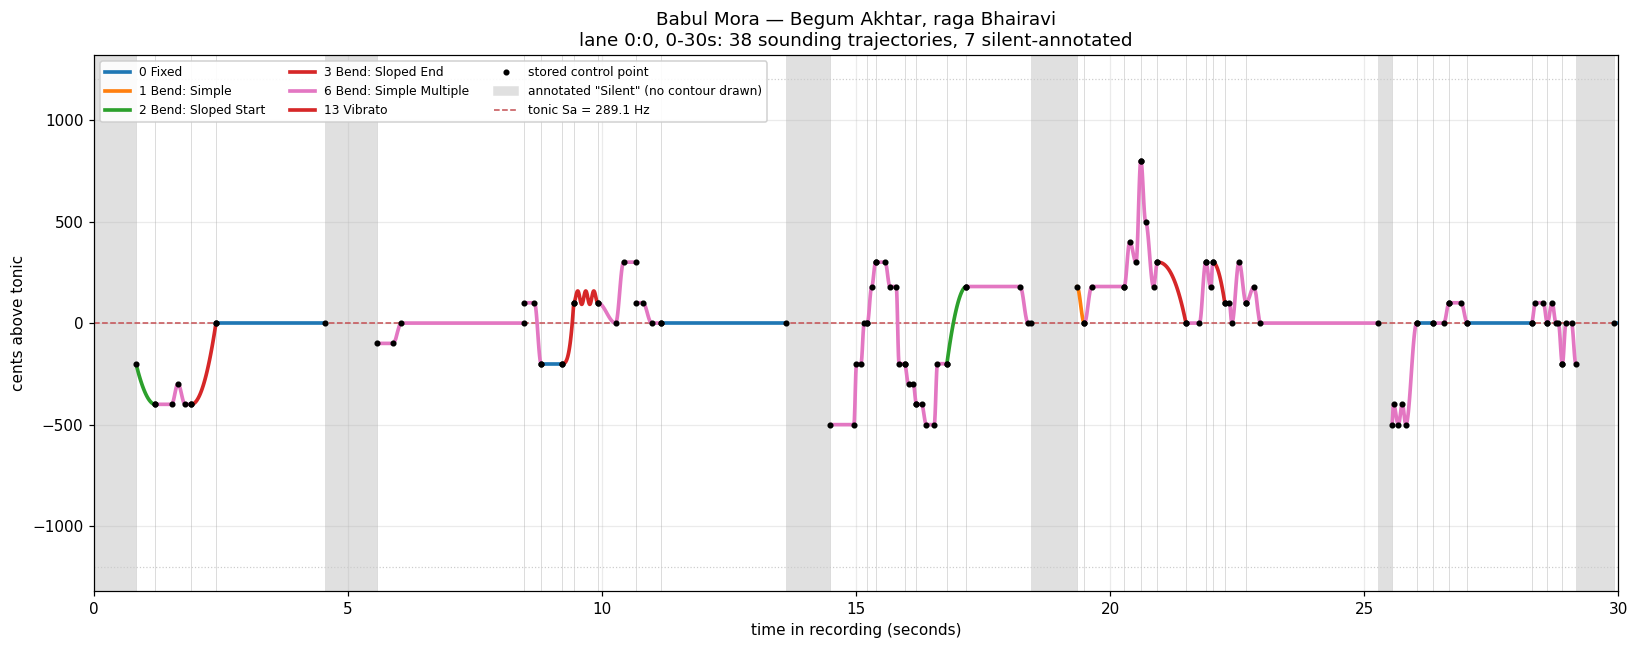

Trajectories in the window, in annotation order:
 idx    start      end     dur type                   shape parameters
   0    0.000    0.826   0.826 Silent                 fund_id12=289.0873718261719
   1    0.826    1.201   0.375 Bend: Sloped Start     n_pitches=2 dur_array=[1] slope=1.905275996087875
   2    1.201    1.916   0.716 Bend: Simple Multiple  n_pitches=5 dur_array=[0.456, 0.174, 0.196, 0.174] slope=2
   3    1.916    2.399   0.483 Bend: Sloped End       n_pitches=2 dur_array=[1] slope=2
   4    2.399    4.549   2.150 Fixed                  n_pitches=2 dur_array=[1] slope=2
   5    4.549    5.554   1.005 Silent                 fund_id12=289.0873718261719
   6    5.554    5.577   0.023 Silent                 fund_id12=289.0873718261719
   7    5.577    8.459   2.882 Bend: Simple Multiple  n_pitches=4 dur_array=[0.108, 0.054, 0.838] slope=2
   8    8.459    8.800   0.340 Bend: Simple Multiple  n_pitches=3 dur_array=[0.615, 0.385] slope=2
   9    8.800    9.212   0.413 Fixed

In [5]:
import warnings

from dataset.canonical.verify_roundtrip import build_from_raw

RECORDING_ID = "645ff354deeaf2d1e33b3c44"   # Babul Mora, Begum Akhtar, densely transcribed
WINDOW = (0.0, 30.0)                         # seconds
LANE = "0:0"
GRID = 80                                    # contour samples per trajectory

doc = docs[RECORDING_ID]
ratios = doc["raga"]["stratified_ratios"]
fundamental = float(doc["raga"]["fundamental_hz"])
tonic_log2 = math.log2(fundamental)

selected = [
    e for e in doc["trajectories"]
    if e["lane_id"] == LANE
    and e["derived"]["end_s"] > WINDOW[0]
    and e["derived"]["start_s"] < WINDOW[1]
]

palette = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(15, 6))
seen_types: dict[int, str] = {}
n_silent = 0

for entry in selected:
    raw, derived = entry["raw"], entry["derived"]
    start, end = derived["start_s"], derived["end_s"]

    if derived["is_silent_annotation"]:
        ax.axvspan(start, end, color="0.88", lw=0, zorder=0)
        n_silent += 1
        continue

    ax.axvline(start, color="0.85", lw=0.6, zorder=1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")   # vocal params on a Sitar default, harmless
        traj = build_from_raw(raw, ratios=ratios, fundamental=fundamental)

    times, cents = [], []
    for step in range(GRID + 1):
        x = step / GRID
        try:
            value = traj.compute(x, log_scale=True)
        except Exception:
            continue
        times.append(start + x * (end - start))
        cents.append(1200 * (value - tonic_log2))

    type_id = derived["type_id"]
    ax.plot(times, cents, color=palette(type_id % 10), lw=2.4, solid_capstyle="round",
            zorder=3)
    seen_types.setdefault(type_id, derived["type_name"])

    # the stored control points the contour was generated from
    for point in derived["control_points"]:
        pitch = point.get("pitch")
        if pitch:
            ax.plot(point["time_s"], pitch["cents_above_tonic"], "o",
                    color="black", ms=3, zorder=4)

ax.axhline(0, color="#c44e52", lw=1, ls="--",
           label=f"tonic Sa = {fundamental:.1f} Hz")
for octave_cents in (-1200, 1200):
    ax.axhline(octave_cents, color="0.8", lw=0.8, ls=":")

handles = [
    plt.Line2D([], [], color=palette(t % 10), lw=2.4, label=f"{t} {name}")
    for t, name in sorted(seen_types.items())
]
handles.append(plt.Line2D([], [], color="black", marker="o", ls="", ms=3,
                          label="stored control point"))
handles.append(plt.Rectangle((0, 0), 1, 1, color="0.88",
                             label='annotated "Silent" (no contour drawn)'))
handles.append(plt.Line2D([], [], color="#c44e52", lw=1, ls="--",
                          label=f"tonic Sa = {fundamental:.1f} Hz"))

ax.set_xlim(*WINDOW)
ax.set_xlabel("time in recording (seconds)")
ax.set_ylabel("cents above tonic")
ax.set_title(
    f"{doc['title']} — {doc['performance']['soloist']}, raga {doc['raga']['name']}\n"
    f"lane {LANE}, {WINDOW[0]:.0f}-{WINDOW[1]:.0f}s: "
    f"{len(selected) - n_silent} sounding trajectories, {n_silent} silent-annotated"
)
ax.legend(handles=handles, fontsize=8, ncol=3, loc="upper left",
          framealpha=0.9)
plt.tight_layout()
plt.show()

print("Trajectories in the window, in annotation order:")
print(f"{'idx':>4} {'start':>8} {'end':>8} {'dur':>7} {'type':<22} shape parameters")
for entry in selected:
    raw, derived = entry["raw"], entry["derived"]
    if derived["is_silent_annotation"]:
        shape = f"fund_id12={raw.get('fund_id12')}"
    else:
        dur_array = raw.get("dur_array")
        shape = (
            f"n_pitches={len(raw['pitches'])} "
            f"dur_array={[round(v, 3) for v in dur_array] if dur_array else None} "
            f"slope={raw.get('slope')}"
        )
    print(
        f"{entry['index']:>4} {derived['start_s']:8.3f} {derived['end_s']:8.3f} "
        f"{derived['duration_s']:7.3f} {derived['type_name']:<22} {shape}"
    )

## Finding 5 — Raw versus derived, and why the separation is trustworthy

Every trajectory carries two blocks. `raw` is a faithful copy of the IDTAP wire fields, with a `wire_keys_present` list recording exactly which keys existed so an absent field never silently becomes an explicit null. `derived` holds everything computed: absolute times, frequencies, cents, and flags.

The point of the split is that derivation logic can change later without re-fetching or losing fidelity. That is only a real guarantee if `raw` is genuinely lossless, so it is tested rather than asserted: each trajectory is rebuilt from its `raw` block alone and its contour compared against one built from the cached verbatim wire response.

The verifier is also checked for the ability to fail — deleting a shape parameter makes it flag exactly the trajectories where that parameter matters.

In [6]:
from dataset.canonical.build import load_raw
from dataset.canonical.verify_roundtrip import check_dispatch_table, verify_recording

# --- one trajectory, both blocks side by side -------------------------------
example = next(
    e for e in docs[RECORDING_ID]["trajectories"]
    if e["derived"]["type_id"] == 2 and e["raw"].get("vowel")
)
print(f"traj_id {example['traj_id']}   (index {example['index']}, lane {example['lane_id']})")
print("\n--- raw: verbatim IDTAP wire values " + "-" * 38)
print(json.dumps(example["raw"], indent=2, sort_keys=True))
print("\n--- derived: everything we computed " + "-" * 38)
print(json.dumps(example["derived"], indent=2, sort_keys=True))

traj_id 645ff354deeaf2d1e33b3c44:0:0:p000:n001   (index 1, lane 0:0)

--- raw: verbatim IDTAP wire values --------------------------------------
{
  "articulations": {},
  "automation": {
    "values": [
      {
        "norm_time": 0,
        "value": 1
      },
      {
        "norm_time": 1,
        "value": 1
      }
    ]
  },
  "dur_array": [
    1
  ],
  "dur_tot": 0.3748795984364197,
  "end_consonant": null,
  "end_consonant_eng_trans": null,
  "end_consonant_hindi": null,
  "end_consonant_ipa": null,
  "fund_id12": null,
  "group_id": null,
  "id": 2,
  "instrumentation": "Vocal (F)",
  "name": "Bend: Sloped Start",
  "num": 1,
  "phrase_index": 0,
  "pitch_wire_keys_present": [
    "fundamental",
    "logOffset",
    "oct",
    "raised",
    "ratios",
    "swara"
  ],
  "pitches": [
    {
      "log_offset": 0,
      "oct": -1,
      "raised": false,
      "swara": 6
    },
    {
      "log_offset": 0,
      "oct": -1,
      "raised": false,
      "swara": 5
    }
  ],
  "slo

In [7]:
# Round-trip verification across the whole corpus. dataset/canonical/verify_roundtrip.py
# runs this as a standalone script; it is inlined here so the numbers are visible.

facts = check_dispatch_table()
print(f"Trajectory.id11 method exists: {facts['has_id11_method']}   "
      f"ids[11] aliases id7: {facts['id11_aliases_id7']}   "
      f"dispatch entries: {facts['n_dispatch_entries']}")

by_type: dict[int, list[float]] = defaultdict(list)
errors: list[dict] = []
n_checked = 0

for recording_id, doc in docs.items():
    piece_json, _ = load_raw(
        recording_id, client=None, repo_root=PROJECT_ROOT, use_cached_raw=True
    )
    for result in verify_recording(
        doc, piece_json, grid_points=41, sample_per_type=0, seed=42
    ):
        n_checked += 1
        delta = result["max_log2_delta"]
        if delta is not None:
            by_type[result["type_id"]].append(delta)
        if result["problems"]:
            errors.append(result)

print(f"\n{n_checked} trajectories rebuilt from their raw block alone\n")
print(f"{'type':>4} {'name':<26} {'n':>6} {'max |delta log2 Hz|':>21}")
for type_id in sorted(by_type):
    deltas = by_type[type_id]
    print(f"{type_id:>4} {TYPE_NAME[type_id]:<26} {len(deltas):>6} {max(deltas):>21.1e}")

n_compared = sum(len(v) for v in by_type.values())
if n_compared != n_checked:
    print(f"\n{n_checked - n_compared} trajectories have no comparable contour: "
          "they are the silent ones missing fund_id12, where Trajectory.compute "
          "raises identically from the raw block and from the wire. That is an "
          "upstream data gap, not a round-trip failure.")

print(f"\ntrajectories with any mismatch: {len(errors)}")
for result in errors[:5]:
    print(f"  {result['traj_id']}: {result['problems'][:2]}")

missing = [t for t in range(14) if t not in by_type]
print(f"\ntypes absent from this corpus, therefore unexercised: {missing}")

Trajectory.id11 method exists: False   ids[11] aliases id7: True   dispatch entries: 14



5209 trajectories rebuilt from their raw block alone

type name                            n   max |delta log2 Hz|
   0 Fixed                        1363               0.0e+00
   1 Bend: Simple                  186               0.0e+00
   2 Bend: Sloped Start            372               0.0e+00
   3 Bend: Sloped End              439               0.0e+00
   4 Bend: Ladle                    96               0.0e+00
   5 Bend: Reverse Ladle            14               0.0e+00
   6 Bend: Simple Multiple        1237               0.0e+00
   7 Krintin                        47               0.0e+00
  12 Silent                       1357               0.0e+00
  13 Vibrato                        95               0.0e+00

3 trajectories have no comparable contour: they are the silent ones missing fund_id12, where Trajectory.compute raises identically from the raw block and from the wire. That is an upstream data gap, not a round-trip failure.

trajectories with any mismatch: 0

types absent

## Finding 6 — Type-0 canonicalization, without destroying the annotation

Two consecutive `Fixed` trajectories at the same pitch are musically equivalent to one longer `Fixed` trajectory, while two at *different* pitches must stay distinct. Rather than collapse the trajectory list, the canonical document carries an **additive overlay**: every trajectory keeps its original entry and gains a `canonical_unit_id`, so the raw and canonical views are both always available.

Pitch identity is exact, over `swara` / `oct` / `raised` / `log_offset`. That last component matters — a few hundred pitches carry a nonzero microtonal `log_offset` — and no adjacent Type-0 pair in this corpus differs *only* by it, so no tolerance is needed. The rule is recorded in `derivation_params.pitch_match_rule` so changing it later is a versioned decision rather than a silent one.

adjacent Fixed->Fixed pairs      : 272
  same pitch (mergeable)         : 66
  different pitch (kept distinct): 206
  crossing a phrase boundary     : 0   (merge_across_phrase_boundary=True)

Fixed trajectories 1363 -> 1297 canonical units (66 collapsed, 54 merged units)
run-length histogram: {1: 5089, 2: 46, 3: 5, 4: 2, 5: 1}


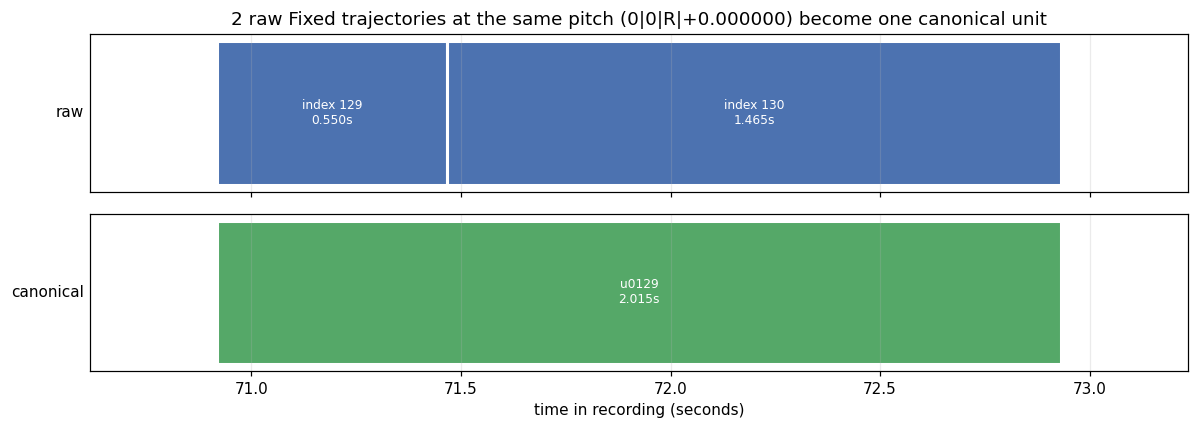

member durations sum to 2.015379s, unit duration is 2.015379s
both raw entries survive in the document; each now carries canonical_unit_id=645ff354deeaf2d1e33b3c44:u0129
  index 129: role=run_start
  index 130: role=run_end


In [8]:
run_lengths: Counter[int] = Counter()
n_merged = 0
for doc in docs.values():
    for length, count in doc["canonicalization"]["run_length_histogram"].items():
        run_lengths[int(length)] += count
    n_merged += doc["canonicalization"]["n_merged_units"]

adjacent_00 = [t for t in transitions if t["both_type_0"] == "True"]
same_pitch = [t for t in adjacent_00 if t["same_pitch"] == "True"]
cross_phrase = [t for t in same_pitch if t["crosses_phrase_boundary"] == "True"]
n_fixed = sum(1 for t in trajectories if int(t["type_id"]) == 0)
fixed_units = len({
    t["canonical_unit_id"] for t in trajectories if int(t["type_id"]) == 0
})

print(f"adjacent Fixed->Fixed pairs      : {len(adjacent_00)}")
print(f"  same pitch (mergeable)         : {len(same_pitch)}")
print(f"  different pitch (kept distinct): {len(adjacent_00) - len(same_pitch)}")
print(f"  crossing a phrase boundary     : {len(cross_phrase)}"
      f"   (merge_across_phrase_boundary="
      f"{ANY_DOC['derivation_params']['type0_merge_across_phrase_boundary']})")
print(f"\nFixed trajectories {n_fixed} -> {fixed_units} canonical units "
      f"({n_fixed - fixed_units} collapsed, {n_merged} merged units)")
print(f"run-length histogram: {dict(sorted(run_lengths.items()))}")

# --- the merge, drawn ------------------------------------------------------
merged = next(
    unit for unit in docs[RECORDING_ID]["canonicalization"]["units"] if unit["merged"]
)
members = [
    e for e in docs[RECORDING_ID]["trajectories"]
    if e["index"] in merged["member_indices"]
]

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 4), sharex=True)
pad = 0.15 * (merged["end_s"] - merged["start_s"])

for entry in members:
    derived = entry["derived"]
    top.barh(0, derived["duration_s"], left=derived["start_s"], height=0.5,
             color="#4c72b0", edgecolor="white", lw=2)
    top.text((derived["start_s"] + derived["end_s"]) / 2, 0,
             f"index {entry['index']}\n{derived['duration_s']:.3f}s",
             ha="center", va="center", color="white", fontsize=8)
top.set_yticks([])
top.set_ylabel("raw", rotation=0, ha="right", va="center")
top.set_title(
    f"{len(members)} raw Fixed trajectories at the same pitch "
    f"({merged['pitch_key']}) become one canonical unit"
)

bottom.barh(0, merged["duration_s"], left=merged["start_s"], height=0.5,
            color="#55a868", edgecolor="white", lw=2)
bottom.text((merged["start_s"] + merged["end_s"]) / 2, 0,
            f"{merged['canonical_unit_id'].split(':')[-1]}\n{merged['duration_s']:.3f}s",
            ha="center", va="center", color="white", fontsize=8)
bottom.set_yticks([])
bottom.set_ylabel("canonical", rotation=0, ha="right", va="center")
bottom.set_xlabel("time in recording (seconds)")
bottom.set_xlim(merged["start_s"] - pad, merged["end_s"] + pad)

plt.tight_layout()
plt.show()

total = sum(e["derived"]["duration_s"] for e in members)
print(f"member durations sum to {total:.6f}s, unit duration is {merged['duration_s']:.6f}s")
print(f"both raw entries survive in the document; each now carries "
      f"canonical_unit_id={merged['canonical_unit_id']}")
for entry in members:
    print(f"  index {entry['index']}: role={entry['derived']['canonical_unit_role']}")

## Finding 7 — Grouped splits, and the leakage they prevent

Splitting on `recording_id` would leak. Several transcriptions in this corpus describe *the same audio file*: one pair shares an `audioID` outright, and a D.V. Paluskar trio has separate `audioID`s whose durations sum to a single performance. Put one in train and another in test and the model is evaluated on audio it trained on.

So the atomic split unit is the **performance group**, assigned by union-find over shared audio ids, a conservative title-normalization rule, and a hand-maintained `overrides.json`. Leakage assertions are recomputed on every run rather than trusted.

The consequence is uncomfortable and worth seeing plainly: 17 recordings collapse to a small number of independent performances, which makes a single 60/20/20 split very coarse. The manifests report the resulting imbalance rather than silently rebalancing to hide it.

14 performance groups from 17 recordings
groups holding more than one transcription: 2
  [CONTAINED] audio:64fedda02f5f4d9c1b63648c -> split ['val']
      6503e36cd9ff49d3988d0b40  D.V. Paluskar - Bhopali
      65b14e207f607fb149202019  D.V. Paluskar, Bhopali Vilambit
      65b2ab707f607fb14920201a  D.V. Paluskar, Bhopali, Jab Se Tumi Sab Laagali
  [CONTAINED] audio:6653cc6dd5788878a197c57d -> split ['train']
      6653ce5fd5788878a197c57f  Chaap Tilak, Abida Parveen & Rahat Fateh Ali Khan
      6653d349d5788878a197c580  Chaap Tilak 2, Abida Parveen & Rahat Ali Khan

leakage assertions (recomputed): {'audio_ids_in_multiple_splits': {}, 'groups_in_multiple_splits': {}, 'n_audio_ids_checked': 16, 'n_groups_checked': 14, 'no_shared_audio_id': True, 'no_shared_group': True}


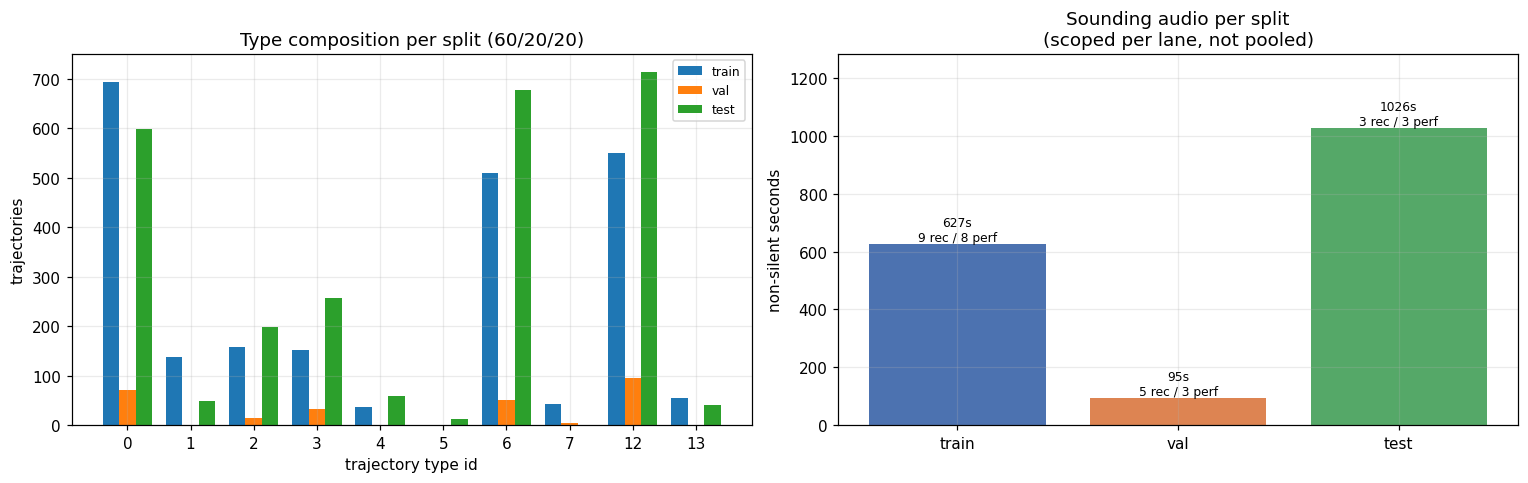

Trajectory types entirely absent from a split:
  train  [5]
  val    [4, 13]
  test   [7]

This is why the k-fold manifest is the more honest instrument:
  fold_0: 5 recordings, 3 performances, 118s sounding
  fold_1: 3 recordings, 3 performances, 688s sounding
  fold_2: 4 recordings, 3 performances, 729s sounding
  fold_3: 3 recordings, 3 performances, 119s sounding
  fold_4: 2 recordings, 2 performances, 93s sounding

Each fold is the held-out set for one CV round; the training set is every recording not assigned to that fold.


In [9]:
ratio_split = load_json(CANONICAL / "splits" / "grouped_60_20_20_seed42.json")
kfold_split = load_json(CANONICAL / "splits" / "grouped_kfold_k5_seed42.json")

multi = {g: m for g, m in ratio_split["group_members"].items() if len(m) > 1}
print(f"{len(ratio_split['group_members'])} performance groups "
      f"from {len(ratio_split['assignments'])} recordings")
print(f"groups holding more than one transcription: {len(multi)}")
for group, members in multi.items():
    split_of = {ratio_split['assignments'][m] for m in members}
    verdict = "CONTAINED" if len(split_of) == 1 else "LEAK"
    print(f"  [{verdict}] {group} -> split {sorted(split_of)}")
    for m in members:
        print(f"      {m}  {docs[m]['title']}")

print(f"\nleakage assertions (recomputed): {ratio_split['leakage_assertions']}")

# --- per-split composition -------------------------------------------------
splits = ["train", "val", "test"]
stats = ratio_split["stats_per_split"]

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 4.5))

width = 0.26
for offset, split in zip((-width, 0, width), splits):
    counts = [stats[split]["type_counts"].get(str(t), 0) for t in TYPE_IDS]
    left.bar([i + offset for i in range(len(TYPE_IDS))], counts, width, label=split)
left.set_xticks(range(len(TYPE_IDS)))
left.set_xticklabels([str(t) for t in TYPE_IDS])
left.set_xlabel("trajectory type id")
left.set_ylabel("trajectories")
left.set_title("Type composition per split (60/20/20)")
left.legend(fontsize=8)

durations = [stats[s]["non_silent_duration_s"] for s in splits]
bars = right.bar(splits, durations,
                 color=["#4c72b0", "#dd8452", "#55a868"])
right.set_ylabel("non-silent seconds")
right.set_title("Sounding audio per split\n(scoped per lane, not pooled)")
for bar, split in zip(bars, splits):
    right.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
               f"{bar.get_height():.0f}s\n{stats[split]['n_recordings']} rec / "
               f"{stats[split]['n_performances']} perf",
               ha="center", va="bottom", fontsize=8)
right.set_ylim(0, max(durations) * 1.25)

plt.tight_layout()
plt.show()

print("Trajectory types entirely absent from a split:")
for split in splits:
    absent = [t for t in TYPE_IDS if stats[split]["type_counts"].get(str(t), 0) == 0]
    print(f"  {split:<6} {absent}")
print("\nThis is why the k-fold manifest is the more honest instrument:")
for fold, values in sorted(kfold_split["stats_per_split"].items()):
    print(f"  {fold}: {values['n_recordings']} recordings, "
          f"{values['n_performances']} performances, "
          f"{values['non_silent_duration_s']:.0f}s sounding")
print(f"\n{kfold_split['fold_usage']}")

## Where this leaves us

**Definitely exists.** Trajectory type, duration, and relative start offsets that are exactly cumulative; ordered discrete pitch control points as `swara`/`oct`/`raised`/`log_offset`; the full shape parameter set (`dur_array`, `slope`, `vib_obj`, `fund_id12`) that regenerates the continuous contour; vowels and consonants on vocal material; chikari strokes on sitar material; raga name, tonic, ratios; soloist, instrumentation, transcriber, dates; phrase and section boundaries with a populated category taxonomy; explicit `Silent` intervals; and gap-free coverage of the full audio duration.

**Does not exist.** End times (only durations). Absolute times (only relative offsets). Meter or tala. Any usable trajectory connectivity — the corpus contains a single group of three trajectories. Onset confidence or annotation-quality ratings. Composition titles. And, critically, **any flag distinguishing a musical rest from an untranscribed region**.

**Reliably derivable.** Absolute start and end times; frequency, log-frequency and cents from the raga tonic; dense sample-accurate f0 contours for the whole sounding timeline via `Trajectory.compute`; interior segment boundaries of composite types; adjacency and pitch continuity between neighbours; per-recording transcription density.

**Requires assumptions.** Whether a `Silent` interval is a rest, a breath, an interlude, or simply untranscribed. Whether trajectory boundaries are perceptual onsets or annotator-chosen subdivisions. Whether a default `slope` of 2.0 was chosen or merely left alone.

**Requires new human annotation.** A transcribed-versus-untranscribed mask per recording — the highest-value and cheapest missing label, roughly one time range per recording. Separating musical rests from non-musical audio such as applause, speech, or tuning. Meter and tala. Onset-precision ratings, before treating boundaries as onset targets.

### The two things most worth acting on

1. **Scope.** 118 transcriptions have audio; 17 are built. Expanding the build is the highest-leverage next step, and it directly addresses the split coarseness seen in Finding 7.
2. **The silence label.** Until untranscribed regions are distinguished from rests, any silence-detection metric computed against type 12 is measuring annotator effort as much as acoustics.